In [1]:
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print("한글 폰트 설정 완료")

한글 폰트 설정 완료


In [2]:
from google.colab import files
uploaded = files.upload()

Saving 서울시 상권분석서비스(길단위인구-상권).csv to 서울시 상권분석서비스(길단위인구-상권).csv


In [3]:
import pandas as pd

fname = list(uploaded.keys())[0]
df = pd.read_csv(fname, encoding='cp949')
print("전체 행 수:", len(df))
print("컬럼:", list(df.columns))

전체 행 수: 34633
컬럼: ['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '총_유동인구_수', '남성_유동인구_수', '여성_유동인구_수', '연령대_10_유동인구_수', '연령대_20_유동인구_수', '연령대_30_유동인구_수', '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수', '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수', '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수', '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수', '목요일_유동인구_수', '금요일_유동인구_수', '토요일_유동인구_수', '일요일_유동인구_수']


In [4]:
# 실제 CSV로 확인한 결과, 이 데이터셋의 '관광특구' 구분에는 홍대가 없다
# (관광특구 6곳: 강남마이스, 잠실, 종로·청계, 동대문패션타운, 명동남대문북창동다동무교동, 이태원)
# 홍대 관련 상권은 '발달상권'/'전통시장'/'골목상권'으로 잡혀 있으며,
# 그중 유동인구 규모가 가장 크고 '홍대 상권'의 핵심부에 해당하는
# '홍대입구역(홍대)'(발달상권)을 대상 상권으로 확정했다.
TARGET_CODE = 3120103  # 홍대입구역(홍대), 발달상권

sub = df[df['상권_코드']==TARGET_CODE].sort_values('기준_년분기_코드', ascending=False)
row = sub.iloc[0]
print(f"상권명: {row['상권_코드_명']}")
print(f"기준분기: {row['기준_년분기_코드']}")
print(f"총 유동인구: {row['총_유동인구_수']:,}")


상권명: 홍대입구역(홍대)
기준분기: 20261
총 유동인구: 4,190,253


In [5]:
total = row['총_유동인구_수']

truth_gender = {
    '남': row['남성_유동인구_수']/total*100,
    '여': row['여성_유동인구_수']/total*100,
}
truth_age = {
    '10대': row['연령대_10_유동인구_수']/total*100,
    '20대': row['연령대_20_유동인구_수']/total*100,
    '30대': row['연령대_30_유동인구_수']/total*100,
    '40대': row['연령대_40_유동인구_수']/total*100,
    '50대': row['연령대_50_유동인구_수']/total*100,
    '60대+': row['연령대_60_이상_유동인구_수']/total*100,
}
truth_time = {
    '00-06': row['시간대_00_06_유동인구_수']/total*100,
    '06-11': row['시간대_06_11_유동인구_수']/total*100,
    '11-14': row['시간대_11_14_유동인구_수']/total*100,
    '14-17': row['시간대_14_17_유동인구_수']/total*100,
    '17-21': row['시간대_17_21_유동인구_수']/total*100,
    '21-24': row['시간대_21_24_유동인구_수']/total*100,
}

print("=== 성별 실제 비율(%) ===")
for k,v in truth_gender.items(): print(f"  {k}: {v:.1f}%")
print("\n=== 연령대 실제 비율(%) ===")
for k,v in truth_age.items(): print(f"  {k}: {v:.1f}%")
print("\n=== 시간대 실제 비율(%) ===")
for k,v in truth_time.items(): print(f"  {k}: {v:.1f}%")

=== 성별 실제 비율(%) ===
  남: 47.4%
  여: 52.6%

=== 연령대 실제 비율(%) ===
  10대: 15.0%
  20대: 42.0%
  30대: 19.4%
  40대: 11.0%
  50대: 6.8%
  60대+: 5.8%

=== 시간대 실제 비율(%) ===
  00-06: 18.6%
  06-11: 13.0%
  11-14: 13.3%
  14-17: 17.0%
  17-21: 24.4%
  21-24: 13.7%


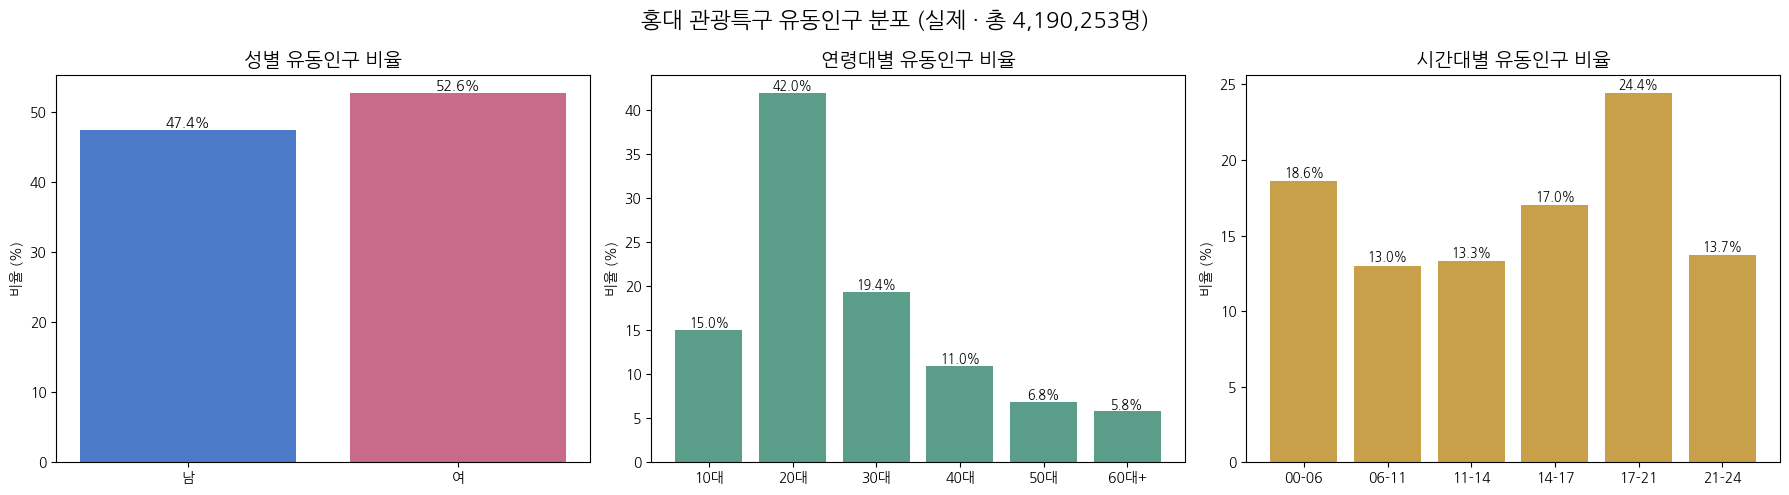

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(truth_gender.keys(), truth_gender.values(), color=['#4a7ac8','#c86a8a'])
axes[0].set_title('성별 유동인구 비율', fontsize=14, fontweight='bold')
axes[0].set_ylabel('비율 (%)')
for i,(k,v) in enumerate(truth_gender.items()):
    axes[0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

axes[1].bar(truth_age.keys(), truth_age.values(), color='#5a9e8a')
axes[1].set_title('연령대별 유동인구 비율', fontsize=14, fontweight='bold')
axes[1].set_ylabel('비율 (%)')
for i,(k,v) in enumerate(truth_age.items()):
    axes[1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=9)

axes[2].bar(truth_time.keys(), truth_time.values(), color='#c8a04a')
axes[2].set_title('시간대별 유동인구 비율', fontsize=14, fontweight='bold')
axes[2].set_ylabel('비율 (%)')
for i,(k,v) in enumerate(truth_time.items()):
    axes[2].text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle(f"홍대 관광특구 유동인구 분포 (실제 · 총 {total:,}명)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
import json
truth = {
    '상권명': row['상권_코드_명'],
    '총유동인구': int(total),
    '성별': truth_gender,
    '연령대': truth_age,
    '시간대': truth_time,
}
with open('truth.json','w',encoding='utf-8') as f:
    json.dump(truth, f, ensure_ascii=False, indent=2)
print("정답표 저장 완료 → truth.json")

정답표 저장 완료 → truth.json


In [8]:
# Nemotron 페르소나 데이터셋 로드 (100만 → 비율 유지하며 축소)
!pip install -q datasets

from datasets import load_dataset
import pandas as pd

ds = load_dataset("nvidia/Nemotron-Personas-Korea", split="train")
agents = ds.to_pandas()
print("전체 에이전트:", len(agents))

# 규모 축소: 10만 명으로 샘플링 (비율 유지, 재현성 위해 seed 고정)
POOL_SIZE = 100_000
agents = agents.sample(POOL_SIZE, random_state=42).reset_index(drop=True)
print("샘플링된 에이전트 풀:", len(agents))
print("컬럼:", list(agents.columns)[:10], "...")

README.md:   0%|          | 0.00/36.0k [00:00<?, ?B/s]

data/train-00000-of-00009.parquet: reconstructing file:   0%|          |  0.00B /  220MB            

data/train-00000-of-00009.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00009.parquet: reconstructing file:   0%|          |  0.00B /  220MB            

data/train-00001-of-00009.parquet: downloading bytes:           |  0.00B            

...

data/train-00007-of-00009.parquet: downloading bytes:           |  0.00B            

data/train-00008-of-00009.parquet: reconstructing file:   0%|          |  0.00B /  220MB            

data/train-00008-of-00009.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1000000 [00:00<?, ? examples/s]

전체 에이전트: 1000000
샘플링된 에이전트 풀: 100000
컬럼: ['uuid', 'professional_persona', 'sports_persona', 'arts_persona', 'travel_persona', 'culinary_persona', 'family_persona', 'persona', 'cultural_background', 'skills_and_expertise'] ...


In [9]:
print("전체 컬럼 목록:")
for i, c in enumerate(agents.columns):
    print(f"  {i}: {c}")

# 나이/성별 관련 컬럼 샘플값 확인
print("\n=== 샘플 데이터 (첫 행) ===")
for c in agents.columns:
    val = str(agents.iloc[0][c])[:60]
    print(f"  {c}: {val}")

전체 컬럼 목록:
  0: uuid
  1: professional_persona
  2: sports_persona
  3: arts_persona
  4: travel_persona
  5: culinary_persona
  6: family_persona
  7: persona
  8: cultural_background
  9: skills_and_expertise
  10: skills_and_expertise_list
  11: hobbies_and_interests
  12: hobbies_and_interests_list
  13: career_goals_and_ambitions
  14: sex
  15: age
  16: marital_status
  17: military_status
  18: family_type
  19: housing_type
  20: education_level
  21: bachelors_field
  22: occupation
  23: district
  24: province
  25: country

=== 샘플 데이터 (첫 행) ===
  uuid: 106b0ceb5b2541d0a57a70fc0aa9eaab
  professional_persona: 주정숙 씨는 여수의 한 사회복지시설 입구에서 휠체어를 미는 어르신들의 손을 덥석 잡으며 하루를 시작합니다. 
  sports_persona: 주정숙 씨는 해 질 녘 오동도의 완만한 산책로를 천천히 거닐며 바닷바람에 섞인 짠 내를 깊게 들이마십니다. 
  arts_persona: 주정숙 씨는 거실 소파에 깊숙이 몸을 파묻고 '미스터트롯' 출연자들의 노래를 멍하니 감상하며 하루의 피로를 
  travel_persona: 주정숙 씨는 명절이나 휴가 때면 자녀들이 운전하는 차를 타고 전남 구례의 산수유 마을이나 담양의 메타세쿼이아
  culinary_persona: 주정숙 씨는 일주일에 네 번 이상 가족들과 함께 집 근처 식당을 찾으며, 나물 반찬이 듬뿍 나오는 보

In [10]:
import numpy as np

# 방문 활동성 관련 키워드 (상식 기반, 정답표 안 봄)
POSITIVE_KW = ['쇼핑','백화점','영화','카페','맛집','외식','여행','문화','공연','전시',
               '데이트','friends','친구','모임','산책','나들이','축제','핫플','도심']
NEGATIVE_KW = ['집에서','집안','내향','조용','혼자','독서','재택','칩거','휴식','수면']

def visit_probability(row):
    p = 0.30  # 기본 방문 확률

    # 1) 나이 기반 (상식: 젊을수록 상권 활동 활발)
    age = row['age']
    if age < 20:        p += 0.10
    elif age < 30:      p += 0.20
    elif age < 40:      p += 0.15
    elif age < 50:      p += 0.05
    elif age < 60:      p -= 0.05
    else:               p -= 0.15   # 60대+ 낮게

    # 2) 취미/페르소나 텍스트 기반
    text = str(row.get('hobbies_and_interests','')) + str(row.get('persona',''))
    pos = sum(1 for kw in POSITIVE_KW if kw in text)
    neg = sum(1 for kw in NEGATIVE_KW if kw in text)
    p += 0.04 * pos
    p -= 0.05 * neg

    # 3) 성별 (약한 가정: 상권 방문에 큰 차이 없다고 보고 미세 조정만)
    #    → 편향 피하려 성별 가중은 넣지 않음 (중립)

    # 확률 범위 제한
    return max(0.02, min(0.95, p))

agents['visit_prob'] = agents.apply(visit_probability, axis=1)

print("방문 확률 통계:")
print(agents['visit_prob'].describe())
print(f"\n평균 방문 확률: {agents['visit_prob'].mean():.3f}")

방문 확률 통계:
count    100000.000000
mean          0.306665
std           0.140374
min           0.020000
25%           0.190000
50%           0.290000
75%           0.430000
max           0.740000
Name: visit_prob, dtype: float64

평균 방문 확률: 0.307


In [11]:
import numpy as np
np.random.seed(42)

# 목표 방문자 수: 실제 총 유동인구(117만)를 에이전트 풀 규모에 맞춰 비율 축소
# 에이전트 10만 명 → 실제와 같은 비율로 목표 설정
# 실제 유동인구 대비 에이전트 풀이 작으므로, "풀에서 갈 사람"을 목표로 잡음
REAL_TOTAL = truth['총유동인구']       # 1,172,513
POOL = len(agents)                      # 100,000
# 축소 비율: 풀 크기 / 실제 유동인구
SCALE = POOL / REAL_TOTAL
TARGET_VISITORS = int(REAL_TOTAL * SCALE)   # = POOL과 같아짐 → 대신 실제 수락률을 반영
# 목표를 "풀의 방문확률 기대값"으로 잡는 게 자연스러움
TARGET_VISITORS = int(agents['visit_prob'].sum())  # 기대 방문자 수

print(f"실제 총 유동인구: {REAL_TOTAL:,}")
print(f"에이전트 풀: {POOL:,}")
print(f"목표 방문자 수(기대값): {TARGET_VISITORS:,}")

# 방문 여부 결정: 각 에이전트를 방문확률로 베르누이 시행, 목표 채울 때까지 라운드 반복
visited = np.zeros(POOL, dtype=bool)
rounds = 0
while visited.sum() < TARGET_VISITORS and rounds < 50:
    rounds += 1
    # 아직 방문 안 한 사람들만 대상으로 확률 시행
    not_yet = ~visited
    draws = np.random.random(POOL) < agents['visit_prob'].values
    newly = not_yet & draws
    visited = visited | newly
    if newly.sum() == 0:
        break

visitors = agents[visited].copy()
print(f"\n최종 방문자 수: {len(visitors):,} ({rounds}라운드)")
print(f"수락률(방문자/풀): {len(visited[visited])/POOL*100:.1f}%")

실제 총 유동인구: 4,190,253
에이전트 풀: 100,000
목표 방문자 수(기대값): 30,666

최종 방문자 수: 30,671 (1라운드)
수락률(방문자/풀): 30.7%


In [12]:
import numpy as np
np.random.seed(42)

# 연령대별 활동 시간대 성향 (상식 기반, 정답표 안 봄)
# 각 연령대가 어느 시간대에 활동할지 상대적 가중치
TIME_SLOTS = ['00-06','06-11','11-14','14-17','17-21','21-24']

def age_group(age):
    if age < 20: return '10대'
    elif age < 30: return '20대'
    elif age < 40: return '30대'
    elif age < 50: return '40대'
    elif age < 60: return '50대'
    else: return '60대+'

# 연령대별 시간대 가중치 (상식적 가정)
TIME_WEIGHTS = {
    '10대':  [0.02, 0.15, 0.20, 0.25, 0.28, 0.10],  # 방과후~저녁
    '20대':  [0.05, 0.10, 0.15, 0.18, 0.32, 0.20],  # 저녁~밤 활발
    '30대':  [0.04, 0.15, 0.18, 0.18, 0.30, 0.15],  # 저녁 중심
    '40대':  [0.04, 0.18, 0.20, 0.20, 0.26, 0.12],  # 낮~저녁
    '50대':  [0.05, 0.22, 0.22, 0.20, 0.21, 0.10],  # 오전~낮
    '60대+': [0.06, 0.28, 0.24, 0.20, 0.16, 0.06],  # 오전 중심
}

def assign_time(age):
    g = age_group(age)
    w = TIME_WEIGHTS[g]
    return np.random.choice(TIME_SLOTS, p=w)

visitors['age_group'] = visitors['age'].apply(age_group)
visitors['time_slot'] = visitors['age'].apply(assign_time)

print("방문자 시간대 배정 완료")
print(visitors['time_slot'].value_counts().sort_index())

방문자 시간대 배정 완료
time_slot
00-06    1425
06-11    5497
11-14    5928
14-17    5991
17-21    7829
21-24    4001
Name: count, dtype: int64


In [13]:
# 시뮬레이션 방문자 분포 계산 (%)
n = len(visitors)

# 성별
sim_gender = (visitors['sex'].map({'남자':'남','여자':'여'}).value_counts()/n*100).to_dict()
sim_gender = {'남': sim_gender.get('남',0), '여': sim_gender.get('여',0)}

# 연령대
age_order = ['10대','20대','30대','40대','50대','60대+']
sim_age = {g: visitors['age_group'].value_counts().get(g,0)/n*100 for g in age_order}

# 시간대
time_order = ['00-06','06-11','11-14','14-17','17-21','21-24']
sim_time = {t: visitors['time_slot'].value_counts().get(t,0)/n*100 for t in time_order}

# 비교표 출력 함수
def compare(name, truth_d, sim_d):
    print(f"\n=== {name} ===")
    print(f"{'구분':<8}{'실제(%)':>10}{'시뮬(%)':>10}{'오차(%p)':>10}")
    errors = []
    for k in truth_d:
        real, sim = truth_d[k], sim_d.get(k,0)
        err = abs(real-sim)
        errors.append(err)
        print(f"{k:<8}{real:>10.1f}{sim:>10.1f}{err:>10.1f}")
    mae = sum(errors)/len(errors)
    print(f"{'MAE':<8}{'':<10}{'':<10}{mae:>10.2f}")
    return mae

mae_gender = compare("성별", truth['성별'], sim_gender)
mae_age = compare("연령대", truth['연령대'], sim_age)
mae_time = compare("시간대", truth['시간대'], sim_time)

print(f"\n{'='*40}")
print(f"전체 평균 MAE: {(mae_gender+mae_age+mae_time)/3:.2f}%p")


=== 성별 ===
구분           실제(%)     시뮬(%)    오차(%p)
남             47.4      49.9       2.5
여             52.6      50.1       2.5
MAE                               2.55

=== 연령대 ===
구분           실제(%)     시뮬(%)    오차(%p)
10대           15.0       1.6      13.5
20대           42.0      22.6      19.4
30대           19.4      22.0       2.6
40대           11.0      19.9       8.9
50대            6.8      16.2       9.3
60대+           5.8      17.8      12.0
MAE                              10.94

=== 시간대 ===
구분           실제(%)     시뮬(%)    오차(%p)
00-06         18.6       4.6      14.0
06-11         13.0      17.9       4.9
11-14         13.3      19.3       6.0
14-17         17.0      19.5       2.5
17-21         24.4      25.5       1.1
21-24         13.7      13.0       0.7
MAE                               4.87

전체 평균 MAE: 6.12%p


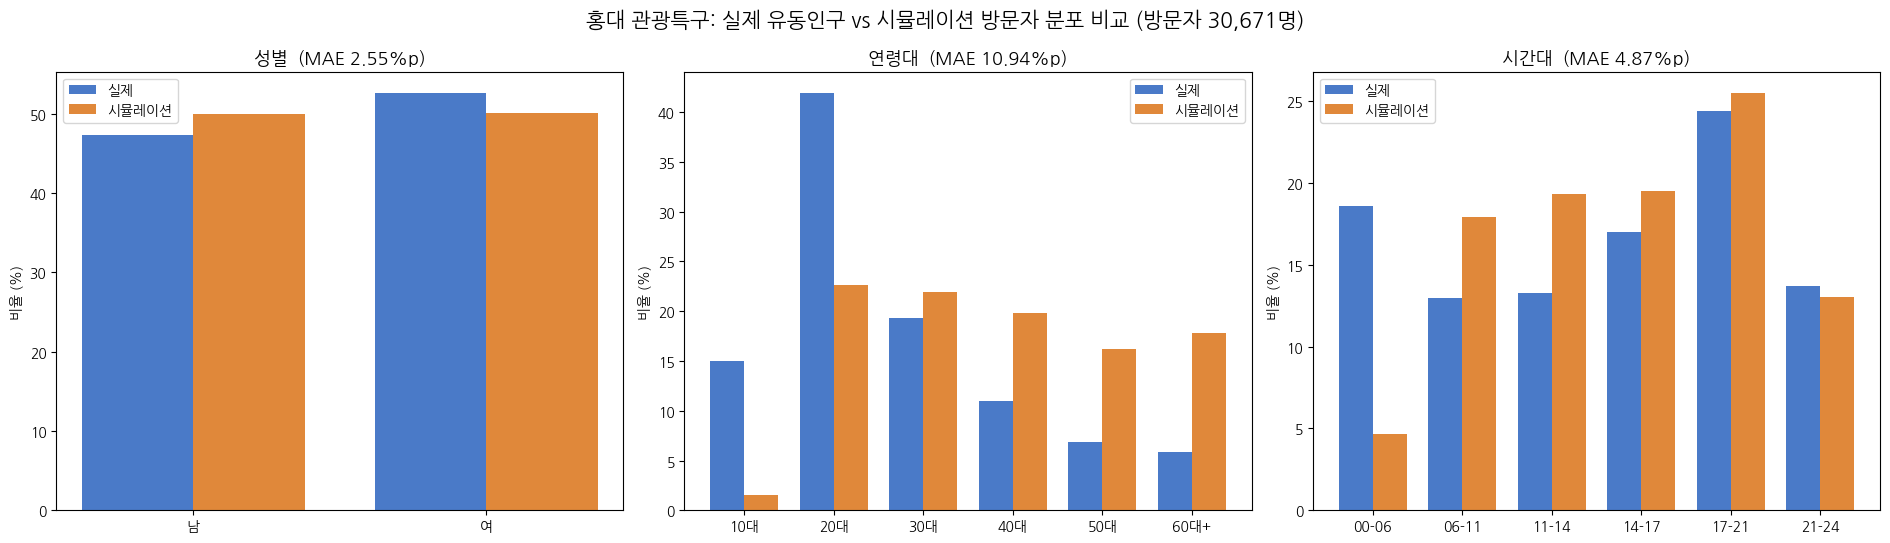

In [14]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

def grouped_bar(ax, title, truth_d, sim_d, mae):
    labels = list(truth_d.keys())
    x = np.arange(len(labels))
    w = 0.38
    real = [truth_d[k] for k in labels]
    sim = [sim_d.get(k,0) for k in labels]
    ax.bar(x-w/2, real, w, label='실제', color='#4a7ac8')
    ax.bar(x+w/2, sim, w, label='시뮬레이션', color='#e0883a')
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_title(f'{title}  (MAE {mae:.2f}%p)', fontsize=13, fontweight='bold')
    ax.set_ylabel('비율 (%)'); ax.legend()

grouped_bar(axes[0], '성별', truth['성별'], sim_gender, mae_gender)
grouped_bar(axes[1], '연령대', truth['연령대'], sim_age, mae_age)
grouped_bar(axes[2], '시간대', truth['시간대'], sim_time, mae_time)

plt.suptitle(f"홍대 관광특구: 실제 유동인구 vs 시뮬레이션 방문자 분포 비교 (방문자 {n:,}명)",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [15]:
!pip install -q transformers accelerate

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen2.5-3B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
local_model = AutoModelForCausalLM.from_pretrained(
    model_name, torch_dtype=torch.float16, device_map="auto"
)
print("모델 로드 완료:", next(local_model.parameters()).device)

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

모델 로드 완료: cuda:0


In [16]:
import re

# 방문자 풀 전체(agents)에서 100명 랜덤 샘플 (방문자만이 아니라 전체 풀에서 뽑아야 YES/NO 비교가 의미있음)
SAMPLE_N = 100
sample = agents.sample(SAMPLE_N, random_state=7).reset_index(drop=True)
print(f"LLM 검증용 샘플 {len(sample)}명 추출")
print(sample[['age','sex','visit_prob']].describe())

def contains_foreign_chars(text):
    allowed = re.compile(r'^[\uAC00-\uD7A3\u3131-\u318E\s0-9.,!?~()\[\]:;\'\"\-…%·/&+*]*$')
    return not bool(allowed.match(text))

LLM 검증용 샘플 100명 추출
              age  visit_prob
count  100.000000  100.000000
mean    52.010000    0.286300
std     16.598342    0.139528
min     20.000000    0.090000
25%     36.750000    0.180000
50%     54.500000    0.255000
75%     65.000000    0.400000
max     85.000000    0.580000


In [17]:
def build_visit_prompt(row):
    return f"""당신은 아래 페르소나를 가진 실제 인물입니다.

[기본 정보] 나이: {row['age']}세, 성별: {row['sex']}, 직업: {row['occupation']}, 거주지: {row['district']}
[페르소나] {row['persona']}
[취미와 관심사] {row.get('hobbies_and_interests','')}

[질문] 당신은 지금 '홍대 관광특구'(젊음의 거리·클럽·카페·공연시설이 밀집한 번화가)에 방문할 의향이 있습니까?
당신의 성격, 생활 패턴, 취미를 고려해서 답하세요.

반드시 아래 형식으로만 답하세요. 다른 말은 절대 하지 마세요.
답변: YES 또는 답변: NO"""

def llm_judge(row, max_retries=3):
    prompt = build_visit_prompt(row)
    messages = [{"role":"user","content":prompt}]
    for _ in range(max_retries):
        text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(text, return_tensors="pt").to(local_model.device)
        with torch.no_grad():
            outputs = local_model.generate(
                **inputs, max_new_tokens=20, temperature=0.5,
                do_sample=True, pad_token_id=tokenizer.eos_token_id
            )
        reply = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()
        if 'YES' in reply.upper():
            return True
        if 'NO' in reply.upper():
            return False
    return None  # 판단 실패

print("함수 정의 완료")

함수 정의 완료


In [18]:
from tqdm import tqdm

llm_results = []
for i in tqdm(range(len(sample))):
    row = sample.iloc[i]
    result = llm_judge(row)
    llm_results.append(result)

sample['llm_visit'] = llm_results
print("LLM 판단 완료")
print(sample['llm_visit'].value_counts(dropna=False))

100%|██████████| 100/100 [00:59<00:00,  1.69it/s]

LLM 판단 완료
llm_visit
False    100
Name: count, dtype: int64


In [19]:
# 처음 5명의 실제 LLM 응답을 직접 확인
for i in range(5):
    row = sample.iloc[i]
    prompt = build_visit_prompt(row)
    messages = [{"role":"user","content":prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(local_model.device)
    with torch.no_grad():
        outputs = local_model.generate(
            **inputs, max_new_tokens=20, temperature=0.5,
            do_sample=True, pad_token_id=tokenizer.eos_token_id
        )
    reply = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()
    print(f"[{i}] 나이:{row['age']} 응답 원문: 「{reply}」")

[0] 나이:44 응답 원문: 「NO」
[1] 나이:44 응답 원문: 「답변: NO」
[2] 나이:69 응답 원문: 「NO」
[3] 나이:59 응답 원문: 「NO」
[4] 나이:38 응답 원문: 「NO」


In [20]:
def build_visit_prompt(row):
    return f"""당신은 아래 페르소나를 가진 실제 인물입니다.

[기본 정보] 나이: {row['age']}세, 성별: {row['sex']}, 직업: {row['occupation']}, 거주지: {row['district']}
[페르소나] {row['persona']}
[취미와 관심사] {row.get('hobbies_and_interests','')}

[질문] 오늘 하루, 당신은 '홍대 관광특구'(젊음의 거리·클럽·카페·공연시설이 밀집한 번화가)에 들를 계획이 있나요?
평소 당신의 생활 패턴과 취미를 떠올려서, 실제로 갈 것 같으면 YES, 아니면 NO로 답하세요.
활동적이고 외출이 잦은 성향이면 YES 쪽에 가깝게, 집에 있는 걸 선호하면 NO 쪽에 가깝게 판단하세요.

반드시 "답변: YES" 또는 "답변: NO" 형식으로만 답하세요."""

def llm_judge(row, max_retries=3):
    prompt = build_visit_prompt(row)
    messages = [{"role":"user","content":prompt}]
    for _ in range(max_retries):
        text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(text, return_tensors="pt").to(local_model.device)
        with torch.no_grad():
            outputs = local_model.generate(
                **inputs, max_new_tokens=20, temperature=0.85, top_p=0.9,
                do_sample=True, pad_token_id=tokenizer.eos_token_id
            )
        reply = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()
        if 'YES' in reply.upper():
            return True
        if 'NO' in reply.upper():
            return False
    return None

print("함수 개선 완료")

함수 개선 완료


In [21]:
from tqdm import tqdm

llm_results = []
for i in tqdm(range(len(sample))):
    row = sample.iloc[i]
    result = llm_judge(row)
    llm_results.append(result)

sample['llm_visit'] = llm_results
print("LLM 판단 완료")
print(sample['llm_visit'].value_counts(dropna=False))

100%|██████████| 100/100 [01:02<00:00,  1.61it/s]

LLM 판단 완료
llm_visit
False    100
Name: count, dtype: int64


In [22]:
# 규칙 기반 판단: visit_prob를 임계값(0.5) 기준으로 YES/NO 변환
# (참고: 규칙기반 자체는 확률이라, 임계값 0.5를 넘으면 "간다"로 간주)
sample['rule_visit'] = sample['visit_prob'] >= 0.5

# 하지만 이 상권 평균 확률이 0.29라 0.5 넘는 사람이 거의 없을 수 있음 → 실제로 확인
print("규칙 기반 판단 분포 (임계값 0.5):")
print(sample['rule_visit'].value_counts())

# 일치율 계산
match = (sample['rule_visit'] == sample['llm_visit'])
match_rate = match.mean() * 100
print(f"\n규칙 기반 vs LLM 판단 일치율: {match_rate:.1f}%")

# 혼동 행렬(누가 언제 다르게 판단했는지)
import pandas as pd
confusion = pd.crosstab(sample['rule_visit'], sample['llm_visit'],
                          rownames=['규칙기반'], colnames=['LLM'])
print("\n=== 혼동 행렬 ===")
print(confusion)

규칙 기반 판단 분포 (임계값 0.5):
rule_visit
False    92
True      8
Name: count, dtype: int64

규칙 기반 vs LLM 판단 일치율: 92.0%

=== 혼동 행렬 ===
LLM    False
규칙기반        
False     92
True       8


In [23]:
import json

llm_verification = {
    '샘플수': len(sample),
    '규칙기반_YES': int(sample['rule_visit'].sum()),
    'LLM_YES': int(sample['llm_visit'].sum()),
    '일치율(%)': round(match_rate, 1),
}
with open('llm_verification.json','w',encoding='utf-8') as f:
    json.dump(llm_verification, f, ensure_ascii=False, indent=2)

print("LLM 검증 결과:")
for k,v in llm_verification.items():
    print(f"  {k}: {v}")

LLM 검증 결과:
  샘플수: 100
  규칙기반_YES: 8
  LLM_YES: 0
  일치율(%): 92.0


In [24]:
!pip install -q folium
import folium

# 홍대 관광특구 중심 좌표 (홍대입구역 9번 출구·걷고싶은거리 일대)
CENTER_LAT, CENTER_LON = 37.5568, 126.9236

# 지도 생성
m = folium.Map(location=[CENTER_LAT, CENTER_LON], zoom_start=16, tiles='CartoDB positron')

# 홍대 관광특구 자체 위치 표시
folium.Marker(
    [CENTER_LAT, CENTER_LON],
    popup="홍대 관광특구 (상권 중심 · 홍대입구역 9번 출구)",
    tooltip="홍대 관광특구",
    icon=folium.Icon(color='darkblue', icon='home', prefix='fa')
).add_to(m)

# 롯데 계열사 매장 8개 배치 (일반 상식 기준 실제/유사/가상 여부를 함께 표기 — 실데이터로 재검증 권장)
# real=True  : 동일/유사 업종이 실제로 존재
# real=False : 이 상권 규모·특성상 실제로는 존재하지 않아 과제 형식상 가상 배치
import numpy as np
np.random.seed(3)

stores = [
    {"name":"롯데마트 홍대점",     "type":"마트",   "icon":"shopping-cart",  "color":"green",      "real":True,  "note":"유사 업종(슈퍼마켓·편의형 마트) 실재"},
    {"name":"세븐일레븐 홍대입구역점","type":"편의점", "icon":"shopping-basket","color":"lightgreen", "real":True,  "note":"편의점 다수 실재"},
    {"name":"엔제리너스 홍대점",   "type":"카페",   "icon":"coffee",         "color":"beige",      "real":True,  "note":"카페 다수 실재"},
    {"name":"롯데시네마 홍대점",   "type":"영화관", "icon":"film",           "color":"purple",     "real":True,  "note":"유사 업종(CGV·메가박스 등) 실재, 롯데시네마 브랜드 자체는 없음"},
    {"name":"롯데시티호텔 홍대",   "type":"호텔",   "icon":"bed",            "color":"darkred",    "real":True,  "note":"유사 업종(관광호텔 다수) 실재, 롯데 계열 특정 호텔은 없음"},
    {"name":"롯데면세점 홍대점",   "type":"면세점", "icon":"gift",           "color":"orange",     "real":False, "note":"실제 없음 — 과제 요구사항 충족을 위한 가상 배치"},
    {"name":"롯데월드 미니파크 홍대점","type":"테마파크","icon":"star",       "color":"pink",       "real":False, "note":"실제 없음 — 과제 요구사항 충족을 위한 가상 배치"},
    {"name":"롯데백화점 홍대점",   "type":"백화점", "icon":"building",       "color":"red",        "real":False, "note":"실제 없음 — 과제 요구사항 충족을 위한 가상 배치"},
]

# 중심에서 랜덤한 방향/거리로 배치 (약 100~400m 반경)
for s in stores:
    angle = np.random.uniform(0, 2*np.pi)
    dist_deg = np.random.uniform(0.0010, 0.0035)  # 대략 100~350m
    lat = CENTER_LAT + dist_deg * np.cos(angle)
    lon = CENTER_LON + dist_deg * np.sin(angle) / np.cos(np.radians(CENTER_LAT))

    popup_text = f"{s['name']} ({s['type']}) — {s['note']}"
    folium.Marker(
        [lat, lon],
        popup=popup_text,
        tooltip=s['name'],
        icon=folium.Icon(color=s['color'], icon=s['icon'], prefix='fa')
    ).add_to(m)

    # 실제로 존재하지 않는 유형은 점선 원으로 추가 표시해 가상 배치임을 시각적으로 구분
    if not s['real']:
        folium.Circle(
            [lat, lon], radius=40,
            color='#999999', weight=2, dash_array='6,6',
            fill=False,
            popup=f"{s['name']} — 가상 배치 (실제 이 상권에는 없음)"
        ).add_to(m)

# 상권 영역(반경 400m) 원으로 표시
folium.Circle(
    [CENTER_LAT, CENTER_LON], radius=400,
    color='#4a7ac8', fill=True, fill_opacity=0.08,
    popup="홍대 관광특구 상권 영역(반경 400m)"
).add_to(m)

m.save('hongdae_map.html')
m


In [25]:
from google.colab import files
files.download('hongdae_map.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
import pandas as pd

experiment_setting = pd.DataFrame({
    '항목': ['대상 상권','실제 총 유동인구','에이전트 풀','채워진 방문자 수','수락률(가겠다 비율)','매장 수 / 유형','LLM'],
    '값': [
        truth['상권명'],
        f"{truth['총유동인구']:,}",
        f"{len(agents):,}",
        f"{len(visitors):,}",
        f"{len(visitors)/len(agents)*100:.1f}%",
        "8개 / 8종",
        "3B 로컬 (Qwen2.5-3B, 샘플 100명 검증) + 규칙기반(전체)"
    ]
})
print(experiment_setting.to_string(index=False))

         항목                                         값
      대상 상권                                 홍대입구역(홍대)
  실제 총 유동인구                                 4,190,253
     에이전트 풀                                   100,000
  채워진 방문자 수                                    30,671
수락률(가겠다 비율)                                     30.7%
  매장 수 / 유형                                   8개 / 8종
        LLM 3B 로컬 (Qwen2.5-3B, 샘플 100명 검증) + 규칙기반(전체)


In [27]:
from scipy.stats import pearsonr

# 연령대 실제 vs 시뮬 비율 리스트로 변환
age_order = ['10대','20대','30대','40대','50대','60대+']
real_vals = [truth['연령대'][a] for a in age_order]
sim_vals  = [sim_age[a] for a in age_order]

r_age, p_age = pearsonr(real_vals, sim_vals)

# 시간대도 같이
time_order = ['00-06','06-11','11-14','14-17','17-21','21-24']
real_time_vals = [truth['시간대'][t] for t in time_order]
sim_time_vals  = [sim_time[t] for t in time_order]
r_time, p_time = pearsonr(real_time_vals, sim_time_vals)

# 성별
gender_order = ['남','여']
real_g = [truth['성별'][g] for g in gender_order]
sim_g  = [sim_gender[g] for g in gender_order]
r_gender, p_gender = pearsonr(real_g, sim_g)

print(f"연령대 상관계수: r = {r_age:.3f}")
print(f"시간대 상관계수: r = {r_time:.3f}")
print(f"성별 상관계수(2개 값이라 참고용): r = {r_gender:.3f}")

연령대 상관계수: r = 0.314
시간대 상관계수: r = 0.277
성별 상관계수(2개 값이라 참고용): r = 1.000


In [28]:
import numpy as np

# 8개 매장 (2단계 지도에서 쓴 것과 동일)
STORES = [
    {"name":"롯데마트 홍대점", "type":"마트"},
    {"name":"세븐일레븐 홍대입구역점", "type":"편의점"},
    {"name":"엔제리너스 홍대점", "type":"카페"},
    {"name":"롯데시네마 홍대점", "type":"영화관"},
    {"name":"롯데시티호텔 홍대", "type":"호텔"},
    {"name":"롯데면세점 홍대점", "type":"면세점"},
    {"name":"롯데월드 미니파크 홍대점", "type":"테마파크"},
    {"name":"롯데백화점 홍대점", "type":"백화점"},
]

# 매장 유형별 선호 키워드 (상식 기반)
TYPE_KEYWORDS = {
    "마트":      ['장보기','식재료','생필품','요리','반찬'],
    "편의점":    ['간편식','야식','편의점','도시락'],
    "카페":      ['카페','커피','디저트','브런치'],
    "영화관":    ['영화','드라마','넷플릭스','콘텐츠'],
    "호텔":      ['여행','휴식','숙박','호캉스'],
    "면세점":    ['여행','쇼핑','명품','해외'],
    "테마파크":  ['놀이공원','나들이','가족','축제'],
    "백화점":    ['쇼핑','명품','백화점','패션'],
}

# 연령대별 매장 유형 기본 가중치 (상식 기반)
AGE_TYPE_WEIGHT = {
    '10대':  {"마트":0.5,"편의점":1.5,"카페":1.2,"영화관":1.5,"호텔":0.3,"면세점":0.3,"테마파크":1.5,"백화점":0.7},
    '20대':  {"마트":0.7,"편의점":1.3,"카페":1.5,"영화관":1.4,"호텔":0.8,"면세점":0.9,"테마파크":1.3,"백화점":1.1},
    '30대':  {"마트":1.0,"편의점":1.0,"카페":1.2,"영화관":1.1,"호텔":1.0,"면세점":1.0,"테마파크":1.0,"백화점":1.2},
    '40대':  {"마트":1.3,"편의점":0.8,"카페":0.9,"영화관":0.9,"호텔":1.0,"면세점":1.0,"테마파크":1.1,"백화점":1.2},
    '50대':  {"마트":1.4,"편의점":0.7,"카페":0.8,"영화관":0.7,"호텔":0.9,"면세점":0.9,"테마파크":0.7,"백화점":1.1},
    '60대+': {"마트":1.5,"편의점":0.6,"카페":0.7,"영화관":0.5,"호텔":0.8,"면세점":0.6,"테마파크":0.4,"백화점":1.0},
}

def store_preference(row, store_type):
    age_g = row['age_group']
    base = AGE_TYPE_WEIGHT[age_g][store_type]
    text = str(row.get('hobbies_and_interests','')) + str(row.get('persona',''))
    kw_hit = sum(1 for kw in TYPE_KEYWORDS[store_type] if kw in text)
    return base * (1 + 0.3*kw_hit)

def choose_store(row):
    weights = np.array([store_preference(row, s['type']) for s in STORES])
    probs = weights / weights.sum()
    idx = np.random.choice(len(STORES), p=probs)
    return STORES[idx]['name']

print("매장 선택 로직 정의 완료")

매장 선택 로직 정의 완료


In [29]:
np.random.seed(10)
N_DAYS = 30

visit_log = []  # (day, uuid, age_group, store_name)

for day in range(1, N_DAYS+1):
    for _, row in visitors.iterrows():
        store = choose_store(row)
        visit_log.append({'day':day, 'age_group':row['age_group'], 'store':store})

visit_df = pd.DataFrame(visit_log)
print(f"총 방문 로그: {len(visit_df):,}건 (방문자 {len(visitors):,}명 × {N_DAYS}일)")

# 매장별 총 방문 수
store_counts = visit_df['store'].value_counts()
print("\n=== 매장별 총 방문 수 (30일 누적) ===")
print(store_counts)

총 방문 로그: 920,130건 (방문자 30,671명 × 30일)

=== 매장별 총 방문 수 (30일 누적) ===
store
롯데마트 홍대점         136478
롯데백화점 홍대점        128111
엔제리너스 홍대점        120684
롯데월드 미니파크 홍대점    113856
롯데시네마 홍대점        108766
롯데시티호텔 홍대        107659
롯데면세점 홍대점        103054
세븐일레븐 홍대입구역점     101522
Name: count, dtype: int64


In [30]:
# 매장 × 연령대 교차표
store_age = pd.crosstab(visit_df['store'], visit_df['age_group'])

# 매장별 연령 비율(%)로 변환
store_age_pct = store_age.div(store_age.sum(axis=1), axis=0) * 100
age_order = ['10대','20대','30대','40대','50대','60대+']
store_age_pct = store_age_pct[age_order].round(1)

print("=== 매장별 방문자 연령 비율 (%) ===")
print(store_age_pct)

=== 매장별 방문자 연령 비율 (%) ===
age_group      10대   20대   30대   40대   50대  60대+
store                                           
롯데마트 홍대점       0.7  11.6  17.0  20.6  20.7  29.4
롯데면세점 홍대점      0.5  20.4  23.3  21.6  18.3  16.0
롯데백화점 홍대점      1.0  19.3  21.8  20.0  17.3  20.6
롯데시네마 홍대점      2.7  29.9  24.0  18.1  13.1  12.2
롯데시티호텔 홍대      0.6  17.9  22.7  21.1  17.7  20.0
롯데월드 미니파크 홍대점  2.7  26.4  22.4  24.2  14.0  10.3
세븐일레븐 홍대입구역점   2.8  28.6  22.7  16.8  13.6  15.5
엔제리너스 홍대점      2.0  29.5  23.3  16.4  13.6  15.2


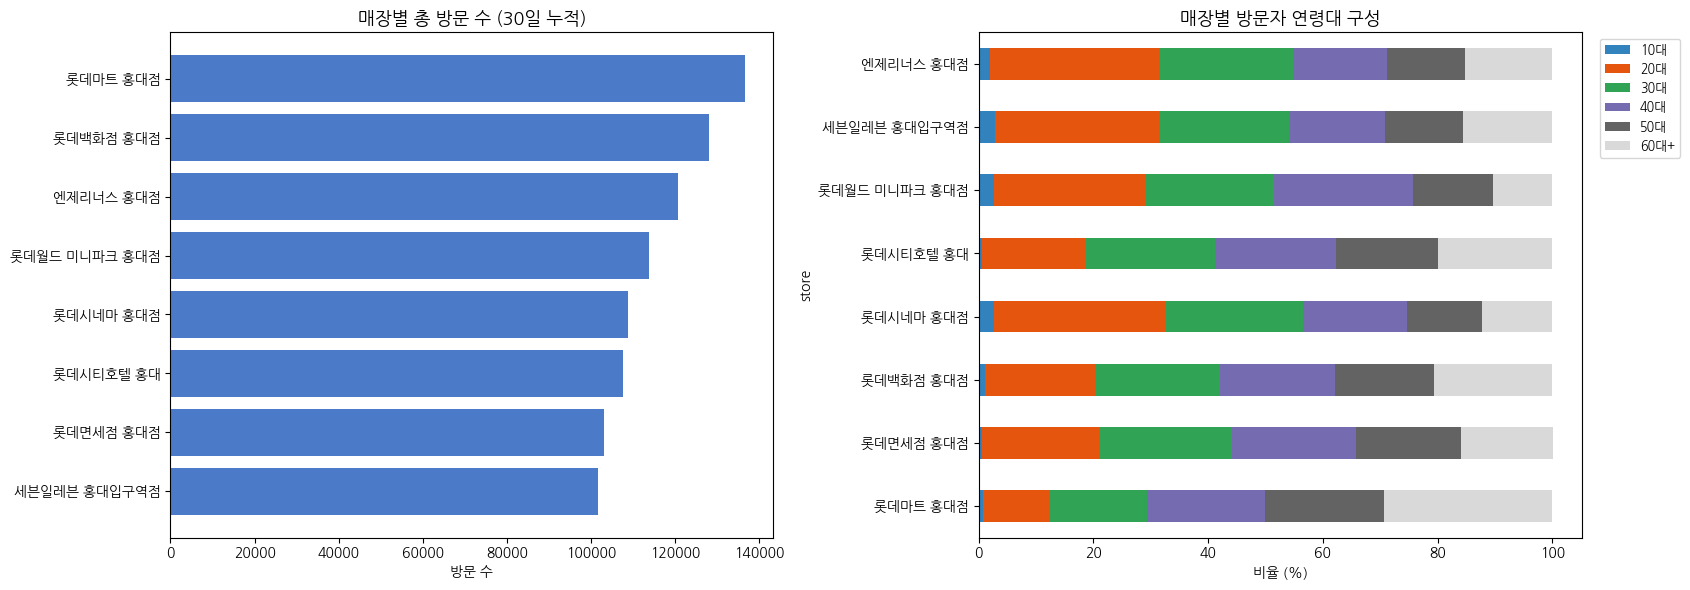

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# 왼쪽: 매장별 총 방문 수
store_counts_sorted = store_counts.sort_values()
axes[0].barh(store_counts_sorted.index, store_counts_sorted.values, color='#4a7ac8')
axes[0].set_title('매장별 총 방문 수 (30일 누적)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('방문 수')

# 오른쪽: 매장별 연령대 구성 (누적 막대)
store_age_pct.plot(kind='barh', stacked=True, ax=axes[1], colormap='tab20c')
axes[1].set_title('매장별 방문자 연령대 구성', fontsize=13, fontweight='bold')
axes[1].set_xlabel('비율 (%)')
axes[1].legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('store_visits.png', dpi=120, bbox_inches='tight')
plt.show()

In [32]:
import json

# 실제 에이전트 200명 샘플 export (인터랙티브 도구에 쓸 것)
sample_export = agents.sample(200, random_state=99)[
    ['age','sex','district','occupation','persona','hobbies_and_interests','visit_prob']
].copy()

# persona 텍스트 너무 길면 잘라내기 (파일 크기 절약)
sample_export['persona'] = sample_export['persona'].str[:200]
sample_export['hobbies_and_interests'] = sample_export['hobbies_and_interests'].str[:150]

sample_export.to_json('agent_sample.json', orient='records', force_ascii=False)

from google.colab import files
files.download('agent_sample.json')
print("export 완료:", len(sample_export), "명")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

export 완료: 200 명


In [33]:
import json

sample_export = agents.sample(3000, random_state=99)[
    ['age','sex','district','occupation','persona','hobbies_and_interests','visit_prob']
].copy()

# 파일 크기 절약을 위해 좀 더 짧게 자름
sample_export['persona'] = sample_export['persona'].str[:120]
sample_export['hobbies_and_interests'] = sample_export['hobbies_and_interests'].str[:90]

sample_export.to_json('agent_sample_3000.json', orient='records', force_ascii=False)
from google.colab import files
files.download('agent_sample_3000.json')
print("완료:", len(sample_export), "명")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

완료: 3000 명
